# Dispersive optical model interface

This notebook demonstrates the supported `jitr.optical_potentials.dom` interface. 

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from jitr.optical_potentials import dom
from jitr.reactions import ElasticReaction
from jitr.utils.kinematics import classical_kinematics_cm

In [12]:
params = {
    'v0': 52.0,
    'v1': 0.006,
    'rv': 1.25,
    'av': 0.65,
    'wv0': 12.0,
    'wv1': 24.0,
    'rw': 1.28,
    'aw': 0.62,
    'ws0': 15.0,
    'ws1': 12.5,
    'ws2': 0.021,
    'rd': 1.28,
    'ad': 0.55,
    'vso0': 6.0,
    'wso0': -3,
    'wso1': 25.0,
    'rso': 1.05,
    'aso': 0.59,
    'rC': 1.25,
}

model = dom.DOM()
param_names = model.params
param_values = [params[name] for name in param_names]
param_names

['v0',
 'v1',
 'rv',
 'av',
 'wv0',
 'wv1',
 'rw',
 'aw',
 'ws0',
 'ws1',
 'ws2',
 'rd',
 'ad',
 'vso0',
 'wso0',
 'wso1',
 'rso',
 'aso',
 'rC']

In [13]:
reaction = ElasticReaction((24, 12), (1, 1))
r_grid = np.linspace(0.1, 12.0, 300)

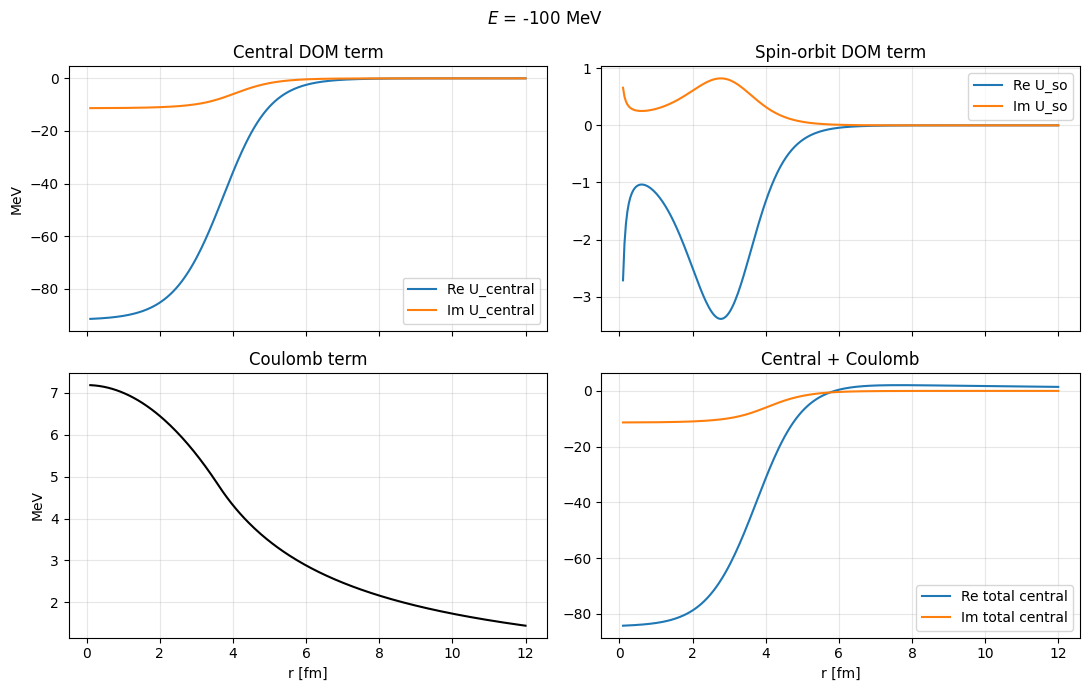

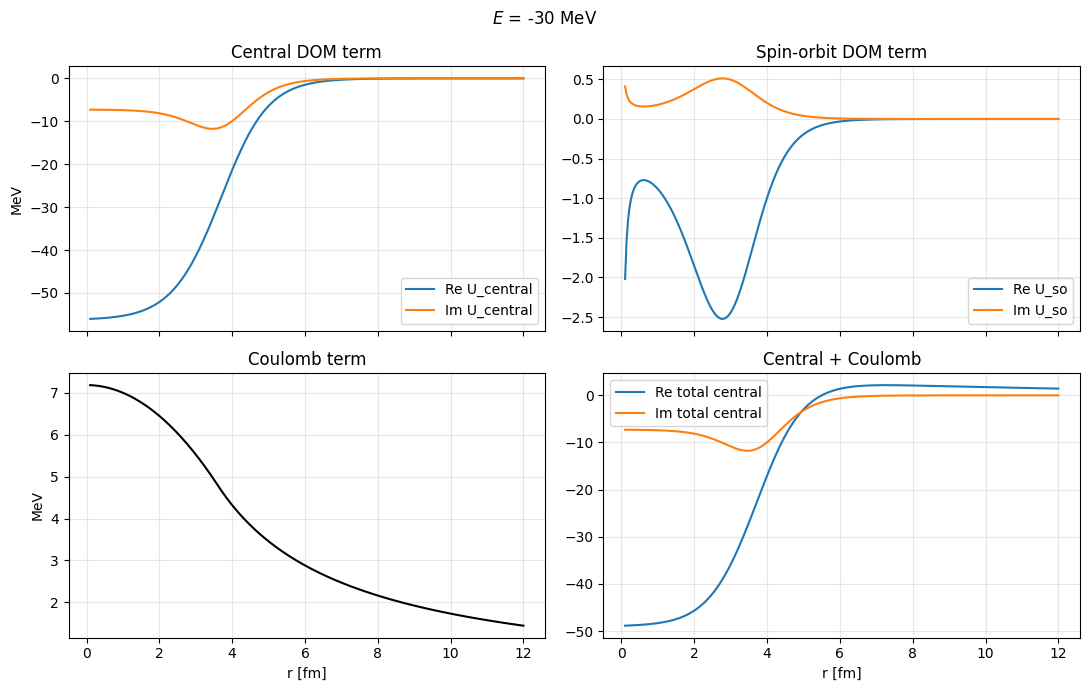

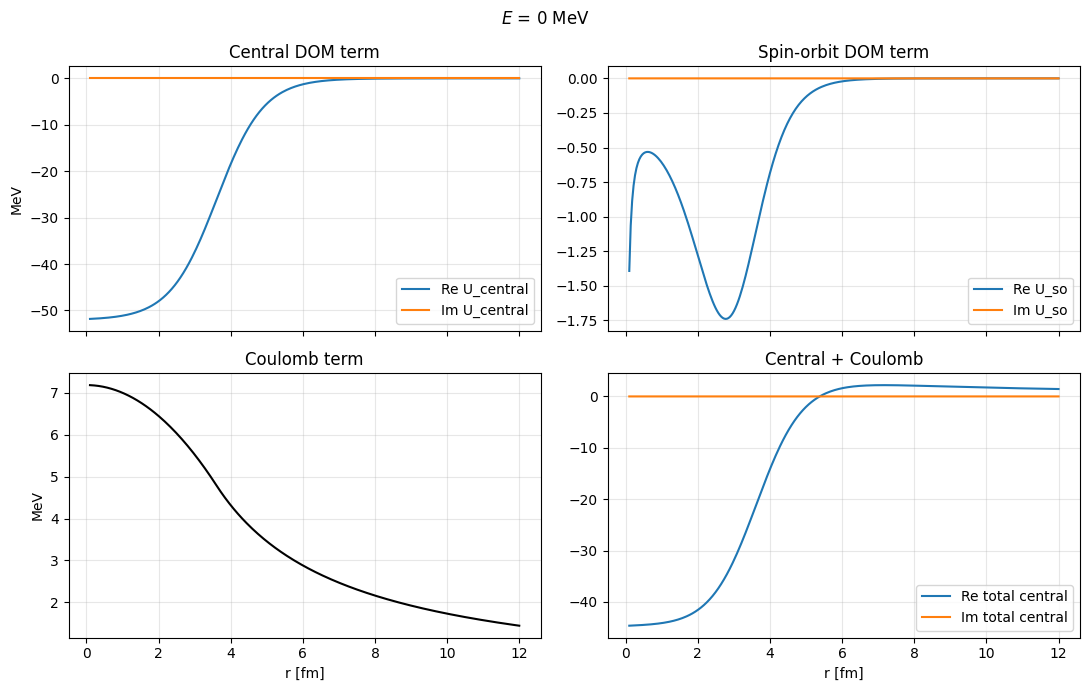

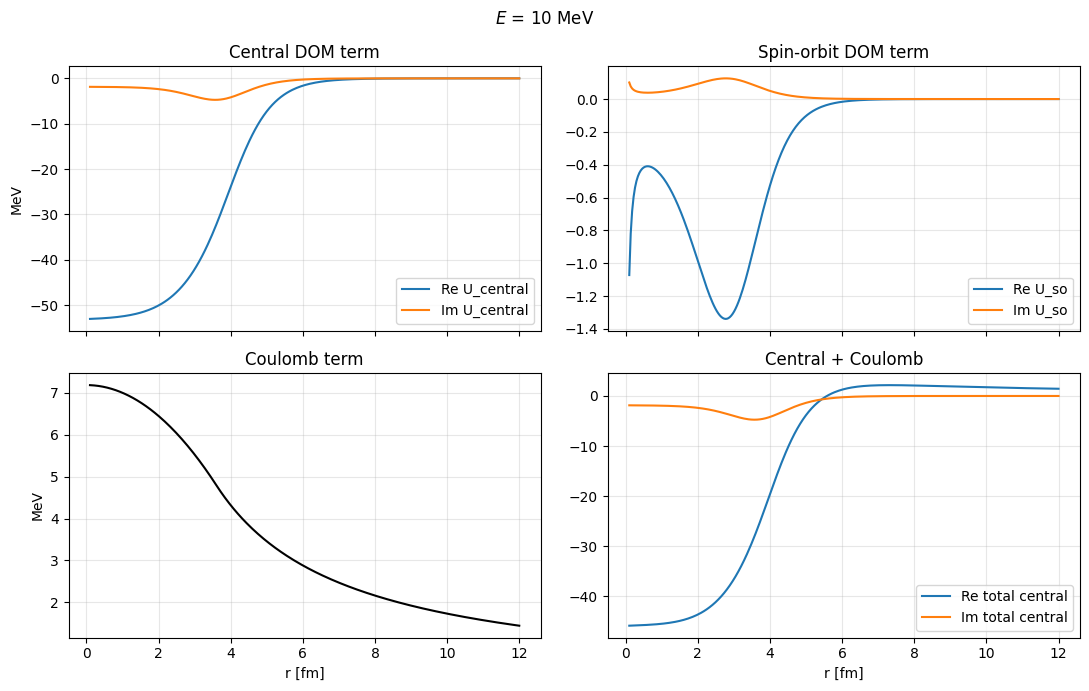

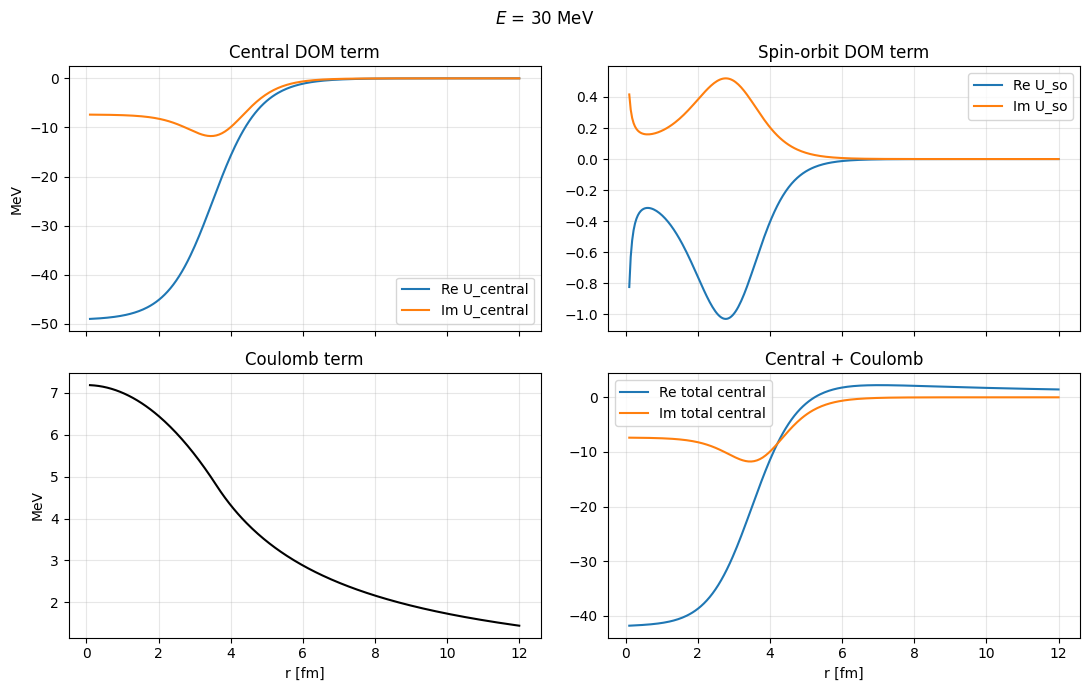

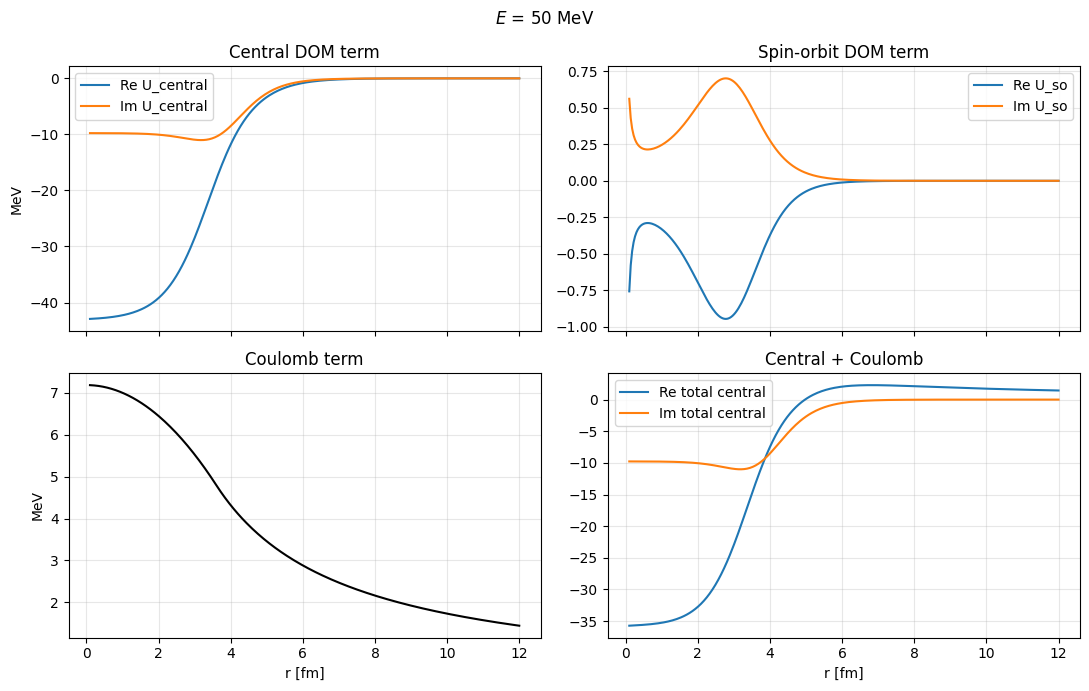

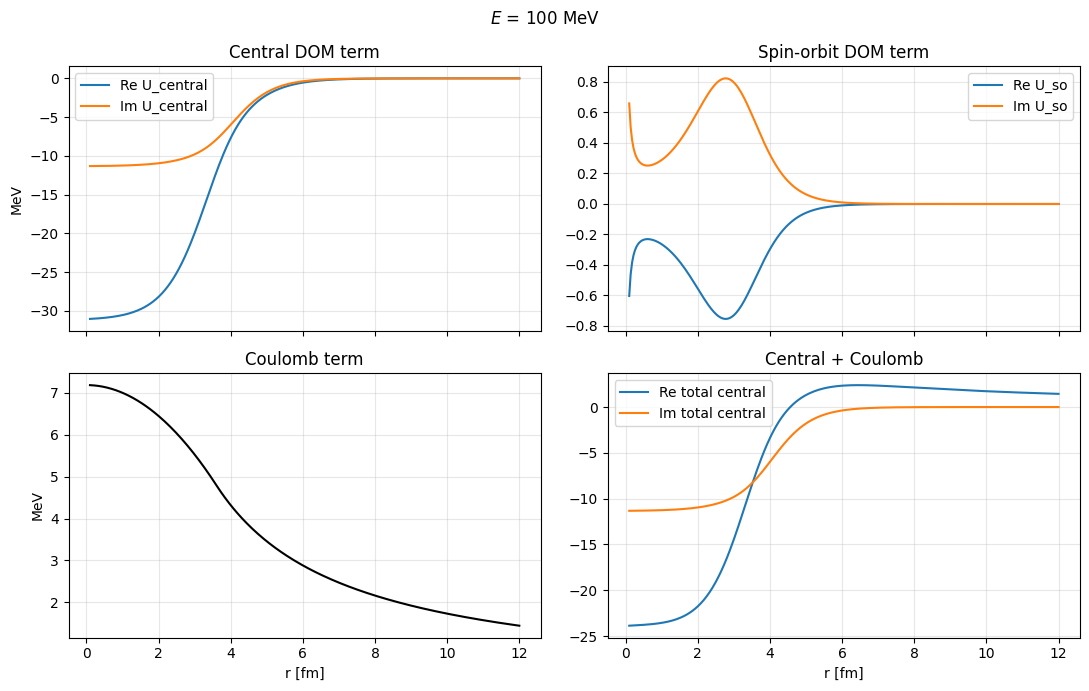

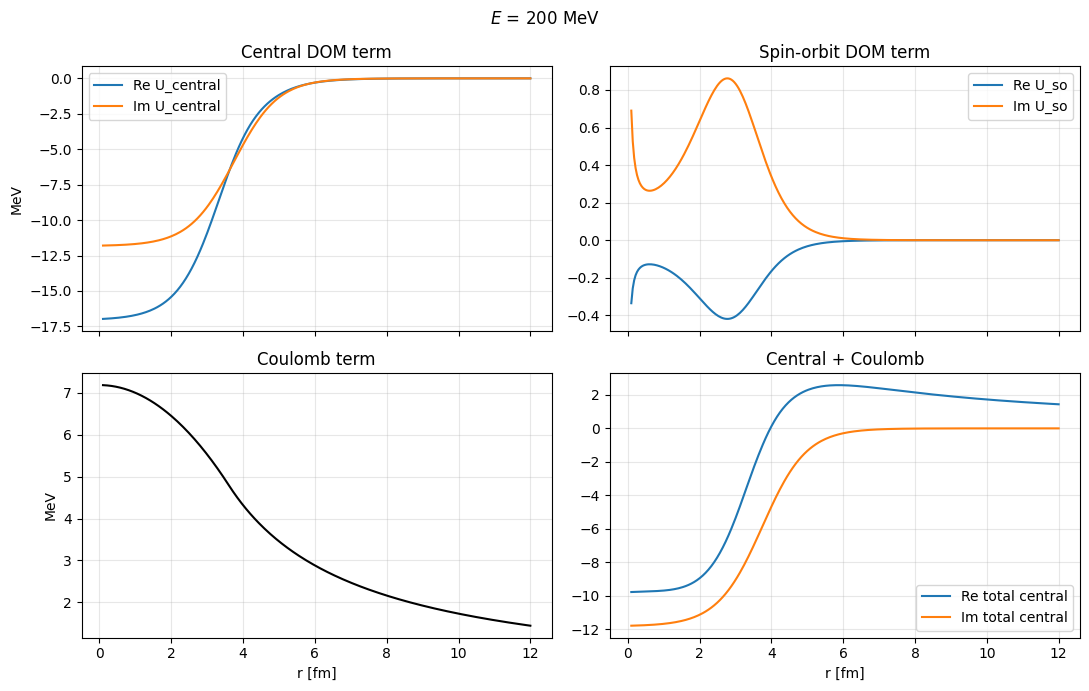

In [15]:
for E in [-100,-30,0,10,30,50,100,200]:
    kinematics = classical_kinematics_cm(
        reaction.target.m0,
        reaction.projectile.m0,
        Ecm=E,
        Zz=reaction.target.Z * reaction.projectile.Z,
    )

    U_central, U_spin_orbit, U_coulomb = model(
        r_grid, reaction, kinematics, *param_values
    )

    fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
    fig.suptitle(f"$E$ = {E} MeV")

    axes[0, 0].plot(r_grid, U_central.real, label='Re U_central')
    axes[0, 0].plot(r_grid, U_central.imag, label='Im U_central')
    axes[0, 0].set_ylabel('MeV')
    axes[0, 0].set_title('Central DOM term')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    axes[0, 1].plot(r_grid, U_spin_orbit.real, label='Re U_so')
    axes[0, 1].plot(r_grid, U_spin_orbit.imag, label='Im U_so')
    axes[0, 1].set_title('Spin-orbit DOM term')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    axes[1, 0].plot(r_grid, U_coulomb, color='black')
    axes[1, 0].set_xlabel('r [fm]')
    axes[1, 0].set_ylabel('MeV')
    axes[1, 0].set_title('Coulomb term')
    axes[1, 0].grid(alpha=0.3)
    
    axes[1, 1].plot(r_grid, (U_central + U_coulomb).real, label='Re total central')
    axes[1, 1].plot(r_grid, (U_central + U_coulomb).imag, label='Im total central')
    axes[1, 1].set_xlabel('r [fm]')
    axes[1, 1].set_title('Central + Coulomb')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    
    fig.tight_layout()